# 3 · Multi-phenotype fine-mapping

Now every individual is measured for **K phenotypes** and we want to borrow strength
across them: a variant causal for several correlated traits should be easier to find
jointly than one trait at a time.

The design is `SharedDesign(X)` — one genotype matrix, `eta = X @ B` of shape `(N, K)`.
Phenotypes are coupled through **two** channels:

1. the **prior** on the K-vector effect (`sushie` = one dense covariance, or `mvsusie`
   = a *mixture* of sharing patterns), and
2. the **likelihood**, when it correlates the phenotype residuals (`mvn_resid`).

We show three flavours:

- **Gaussian** multi-phenotype via `mvn_resid` (residual covariance across traits),
- **non-Gaussian** multi-phenotype (two binary traits, `bernoulli_logit`),
- a **mixed** likelihood (one continuous + one binary trait) via a tiny custom composite.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
rng = np.random.default_rng(0)  # NumPy RNG for the simulations (deterministic)

In [2]:
def plot_pips(pip, causal, title, ax=None):
    """Stem plot of per-variant PIPs, with the true causal variants highlighted."""
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3))
    m = np.arange(len(pip))
    ax.vlines(m, 0, pip, color="0.75", lw=1)
    ax.scatter(m, pip, s=12, color="0.4", label="variants")
    ax.scatter(causal, np.asarray(pip)[list(causal)], s=70, color="crimson",
               zorder=3, label="true causal")
    ax.set(xlabel="variant index", ylabel="PIP", ylim=(-0.02, 1.05), title=title)
    ax.legend(loc="upper right", frameon=True)
    return ax


def credible_set_table(result):
    """Tidy DataFrame summarising the credible sets that passed the purity filter."""
    rows = []
    for cs in result.credible_sets:
        if not cs.kept:
            continue
        rows.append({
            "effect": cs.effect,
            "size": len(cs.variants),
            "coverage": round(float(cs.coverage), 3),
            "purity": round(float(cs.purity), 3),
            "variants": list(np.asarray(cs.variants)[:8]),
        })
    return pd.DataFrame(rows)


## A · Gaussian multi-phenotype (`mvn_resid`)

Two correlated continuous phenotypes share a causal variant `j`. `mvn_resid` carries the
`K x K` residual covariance `Sigma_e`; the `sushie` prior puts a single dense covariance
on the effect vector so the two traits' effects are estimated jointly.

In [3]:
from lasusie import finemap, Model, likelihoods, priors
from lasusie.design import SharedDesign

N, M, j = 400, 80, 25
K = 2
X = rng.standard_normal((N, M))
X = (X - X.mean(0)) / X.std(0)

effects = np.array([1.2, 0.9])                 # per-phenotype effect of variant j
resid_rho = 0.5                                # residual correlation across phenotypes
Sigma_e = np.array([[1.0, resid_rho], [resid_rho, 1.0]])
noise = rng.standard_normal((N, K)) @ np.linalg.cholesky(Sigma_e).T
Y = np.outer(X[:, j], effects) + noise
print("Y:", Y.shape)

Y: (400, 2)


top variant = 25  (true = 25),  PIP = 1.000


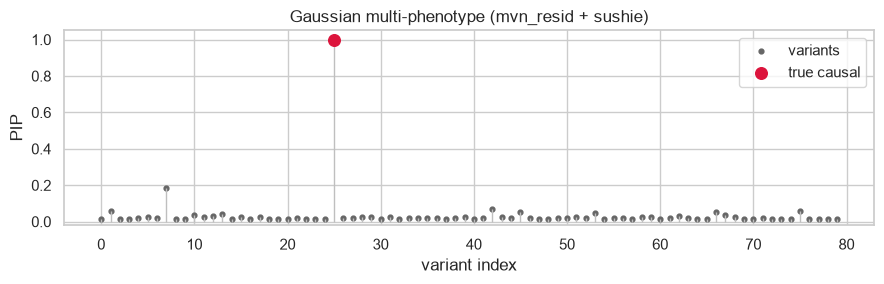

,effect,size,coverage,purity,variants
0,0,1,1.0,1.0,[25]


In [4]:
gauss_model = Model(
    design=SharedDesign(X=jnp.asarray(X)),
    likelihood=likelihoods.mvn_resid(jnp.asarray(Y), resid_cov=jnp.asarray(Sigma_e)),
    prior=priors.sushie(jnp.eye(K)),
    log_pi=jnp.full(M, -jnp.log(M)),
)
gauss_res = finemap(gauss_model, L=3, coverage=0.95, purity=0.5)
print(f"top variant = {int(np.argmax(gauss_res.pip))}  (true = {j}),  PIP = {gauss_res.pip[j]:.3f}")

plot_pips(gauss_res.pip, [j], "Gaussian multi-phenotype (mvn_resid + sushie)")
plt.tight_layout(); plt.show()
credible_set_table(gauss_res)

### The mixture prior (mvSuSiE)

If you don't know *how* an effect is shared across traits, use `mvsusie` with
`canonical_components`: a mixture over standard sharing patterns (fully shared,
independent, trait-specific, null). The mixing weights are learned by empirical Bayes.

> **Which `ser_fit`?** For a **Gaussian** likelihood the conjugate SER is *exact* and needs
> only one Laplace fit per variant, so we pass `ser_fit="conjugate"` here — both exact and
> cheaper than the default `"joint"` (which fits the MAP of each mixture component
> separately, `G` fits per variant); the two agree to floating-point precision on a Gaussian
> likelihood. `"joint"` earns its extra cost on **non-Gaussian** mixtures, where the
> conjugate path's likelihood-only mode can diverge (a count / exp-family null variant has no
> interior maximum) and the per-component prior curvature `Σ_g⁻¹` regularises it at the
> source. Both paths handle the rank-deficient canonical components (e.g. the fully-shared
> `[[1,1],[1,1]]`) in single or double precision — the joint fit keeps them invertible with a
> dtype-relative ridge.

In [5]:
from lasusie.priors import canonical_components

mix_model = Model(
    design=SharedDesign(X=jnp.asarray(X)),
    likelihood=likelihoods.mvn_resid(jnp.asarray(Y)),          # default Sigma_e = I, EB-updated
    prior=priors.mvsusie(canonical_components(K=K, scale=1.0)),
    log_pi=jnp.full(M, -jnp.log(M)),
)
mix_res = finemap(mix_model, L=3, coverage=0.95, purity=0.5,
                  update_prior=True, ser_fit="conjugate")
print(f"mvSuSiE mixture: top variant = {int(np.argmax(mix_res.pip))}  (true = {j}),  "
      f"PIP = {mix_res.pip[j]:.3f}")

mvSuSiE mixture: top variant = 25  (true = 25),  PIP = 1.000


## B · Non-Gaussian multi-phenotype (two binary traits)

`SharedDesign` gives `eta` of shape `(N, K)`; a pointwise likelihood like
`bernoulli_logit` is just applied elementwise, so it handles `K` binary phenotypes with
no extra machinery. The traits are coupled through the `sushie` prior on the shared
effect vector.

Yb balance per trait: [0.48 0.48]


binary multi-pheno: top variant = 25  (true = 25),  PIP = 1.000


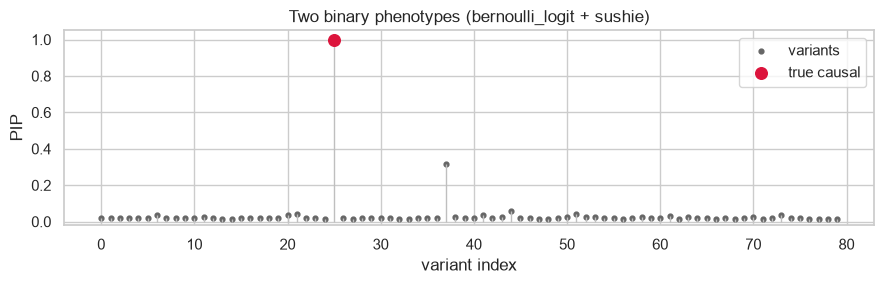

In [6]:
lin = np.outer(X[:, j], np.array([1.5, 1.2]))          # logit-scale signal at variant j
probs = 1.0 / (1.0 + np.exp(-lin))
Yb = rng.binomial(1, probs).astype(float)              # (N, K) binary phenotypes
print("Yb balance per trait:", Yb.mean(0).round(2))

bern_model = Model(
    design=SharedDesign(X=jnp.asarray(X)),
    likelihood=likelihoods.bernoulli_logit(jnp.asarray(Yb)),
    prior=priors.sushie(jnp.eye(K) * 4.0),             # wider prior for logit-scale effects
    log_pi=jnp.full(M, -jnp.log(M)),
)
bern_res = finemap(bern_model, L=3, coverage=0.95, purity=0.5)
print(f"binary multi-pheno: top variant = {int(np.argmax(bern_res.pip))}  (true = {j}),  "
      f"PIP = {bern_res.pip[j]:.3f}")

plot_pips(bern_res.pip, [j], "Two binary phenotypes (bernoulli_logit + sushie)")
plt.tight_layout(); plt.show()

## C · Mixed likelihood (continuous + binary)

What if the phenotypes are of *different types* — say one continuous and one binary? A
likelihood only has to answer three questions (`log_density`, `expected_log_density`,
`updated`; see the [extending guide](../docs/extending/likelihood.md)). We can build a
**mixed** likelihood by delegating each column of `eta` to a per-trait pointwise
likelihood and summing. The built-in `gaussian` / `bernoulli_logit` factories already
provide exact per-column expectations, so the composite is a few lines.

In [7]:
import equinox as eqx


class MixedColumns(eqx.Module):
    """A per-column mix of pointwise likelihoods for multi-phenotype `eta` of shape (N, K).

    Column k of `eta` is scored by `liks[k]`. Because each built-in pointwise likelihood
    already supplies an (exact, Gauss-Hermite) `expected_log_density` and an EB `updated`,
    the composite just delegates column-by-column and sums.
    """

    liks: list

    def log_density(self, eta):
        return sum(lik.log_density(eta[:, k]) for k, lik in enumerate(self.liks))

    def expected_log_density(self, mean, var):
        return sum(lik.expected_log_density(mean[:, k], var[:, k])
                   for k, lik in enumerate(self.liks))

    def updated(self, eta_mean, eta_var):
        return MixedColumns(liks=[lik.updated(eta_mean[:, k], eta_var[:, k])
                                  for k, lik in enumerate(self.liks)])


mixed likelihood: top variant = 25  (true = 25),  PIP = 1.000


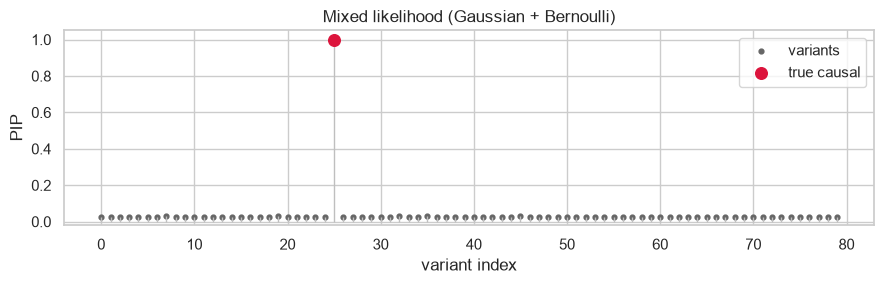

,effect,size,coverage,purity,variants
0,0,1,1.0,1.0,[25]


In [8]:
# phenotype 0: continuous Gaussian;  phenotype 1: binary
y_cont = X[:, j] * 1.0 + rng.standard_normal(N) * 1.0
p_bin = 1.0 / (1.0 + np.exp(-(X[:, j] * 1.5)))
y_bin = rng.binomial(1, p_bin).astype(float)

mixed_lik = MixedColumns(liks=[
    likelihoods.gaussian(jnp.asarray(y_cont), sigma2=1.0),   # column 0
    likelihoods.bernoulli_logit(jnp.asarray(y_bin)),         # column 1
])

mixed_model = Model(
    design=SharedDesign(X=jnp.asarray(X)),
    likelihood=mixed_lik,
    prior=priors.sushie(jnp.eye(K) * 2.0),
    log_pi=jnp.full(M, -jnp.log(M)),
)
mixed_res = finemap(mixed_model, L=3, coverage=0.95, purity=0.5)
print(f"mixed likelihood: top variant = {int(np.argmax(mixed_res.pip))}  (true = {j}),  "
      f"PIP = {mixed_res.pip[j]:.3f}")

plot_pips(mixed_res.pip, [j], "Mixed likelihood (Gaussian + Bernoulli)")
plt.tight_layout(); plt.show()
credible_set_table(mixed_res)

The same `Model` machinery fine-maps a continuous and a binary phenotype jointly, sharing
information through the prior on the effect vector. The custom `MixedColumns` class is all
it took — any object with `log_density` / `expected_log_density` / `updated` is a valid
likelihood axis.